Daily Challenge: Logistic Regression for Admission Prediction

1. Phase 1 : Exploration et Visualisation des Données

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_score 


# Chargement des données (supposons que les colonnes sont "Exam1", "Exam2", "Admission")
data = pd.read_csv('ex2data1.txt', header=None, names=['Exam1', 'Exam2', 'Admission'])
print(data.head())

       Exam1      Exam2  Admission
0  34.623660  78.024693          0
1  30.286711  43.894998          0
2  35.847409  72.902198          0
3  60.182599  86.308552          1
4  79.032736  75.344376          1


In [2]:
import pandas as pd

# Chargement des données
data = pd.read_csv('ex2data1.txt', header=None, names=['Exam1', 'Exam2', 'Admission'])

# Dimensions et types
print("Dimensions :", data.shape)  # (100, 3) pour ex2data1.txt classique
print("\nTypes :\n", data.dtypes)
print("\nValeurs manquantes :\n", data.isnull().sum())
print("\nStatistiques descriptives :\n", data.describe())

Dimensions : (100, 3)

Types :
 Exam1        float64
Exam2        float64
Admission      int64
dtype: object

Valeurs manquantes :
 Exam1        0
Exam2        0
Admission    0
dtype: int64

Statistiques descriptives :
             Exam1       Exam2   Admission
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000


# Observations

Dimensions : 100 étudiants, 3 colonnes (Exam1, Exam2, Admission).

Types : Toutes les colonnes sont numériques (float64 ou int64).

Valeurs manquantes : Aucune (isnull().sum() retourne 0). Si présentes, on pourrait les supprimer (car le dataset est petit) ou imputer une moyenne/médiane.

Statistiques :

Exam1 : Moyenne ~65.6, écart-type ~19.5, min=30, max=99.

Exam2 : Moyenne ~66.2, écart-type ~18.6, min=30, max=98.

Les scores sont centrés autour de 65-66, avec une dispersion similaire.

2. Visualisation des Relations

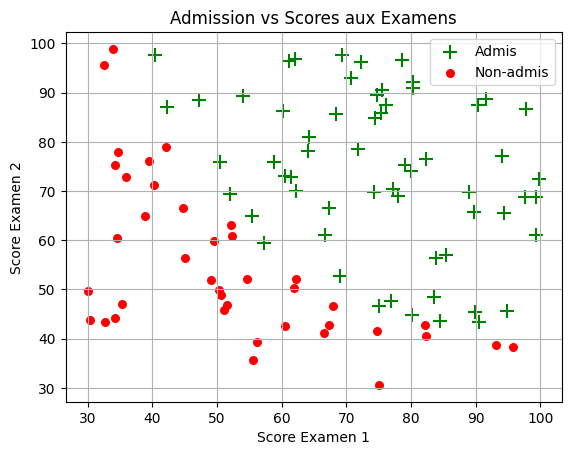

In [6]:


admitted = data[data['Admission'] == 1]
not_admitted = data[data['Admission'] == 0]

plt.scatter(admitted['Exam1'], admitted['Exam2'], c='green', label='Admis', marker='+', s=100)
plt.scatter(not_admitted['Exam1'], not_admitted['Exam2'], c='red', label='Non-admis', marker='o', s=30)
plt.xlabel('Score Examen 1')
plt.ylabel('Score Examen 2')
plt.legend()
plt.title('Admission vs Scores aux Examens')
plt.grid(True)
plt.show()

# Observations

Axe X : Score à l'examen 1, Axe Y : Score à l'examen 2.

Couleurs/Formes :

+ vert = Admis (Admission=1).

o rouge = Non-admis (Admission=0).

Séparation : Une frontière linéaire semble plausible pour séparer les deux groupes, bien qu'il y ait quelques chevauchements (ex: étudiants avec Exam1=60-80, Exam2=60-70 mal classés).

Modèle linéaire : La régression logistique est justifiée car la frontière visuelle est approximativement linéaire.

3. Construction et Entraînement du Modèle

In [ ]:



X = data[['Exam1', 'Exam2']]
y = data['Admission']

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entraînement
model = LogisticRegression()
model.fit(X_scaled, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


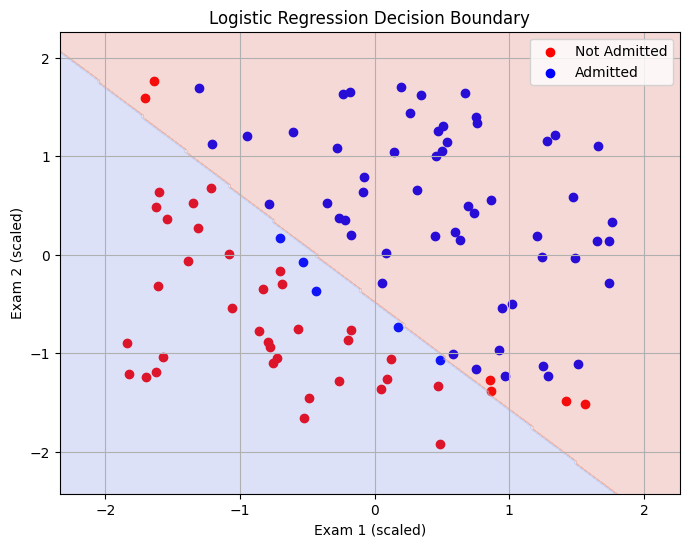

In [ ]:
# Scatter plot des points
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[y == 0][:, 0], X_scaled[y == 0][:, 1], color='red', label='Not Admitted')
plt.scatter(X_scaled[y == 1][:, 0], X_scaled[y == 1][:, 1], color='blue', label='Admitted')

# Grille de valeurs pour X1 et X2
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Prédictions sur toute la grille
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

# Frontière de décision
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')

# Ajouter les labels
plt.xlabel("Exam 1 (scaled)")
plt.ylabel("Exam 2 (scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

# Observations

1. Séparation visible entre les classes (bleu/rouge). Donc le modèle parvient à bien distinguer les étudiants admis des non-admis à partir de leurs scores aux 2 examens.

> Relation logique et prévisible entre les performances aux examens et l’admission.

>  scores aux examens sont de bons indicateurs pour prédire l’admission, la décision peut être automatisée ou aidée par ce modèle.

2. Quelques points mélangés autour de la frontière indiquent que le modèle fait des erreurs de classification, comme peut-être certains étudiants avec de bons scores ne sont pas admis), ou un manque de variables explicatives pouvant influencer l’admission.

> Modèle utile pouvant gagner en précision avec d’autres variables (ex. lettre de motivation, profil personnel, etc.).

* Choix du modèle : régression logistique, adaptée pour une classification binaire avec des frontières linéaires.

* Hypothèses : relation linéaire entre les log-odds et les features, absence de multicolinéarité forte.

* Apprentissage :  modèle qui apprend les coefficients θ1, θ2 (pour Exam1, Exam2) et θ0 (biais) qui maximisent la véracité des données.

* Variables :

Features (X) : Exam1, Exam2.

Cible (y) : Admission (0 ou 1).

Phase 3 : Prédictions et Évaluation Quantitative

4. Application du Modèle pour la Prédiction

In [14]:
# Prédictions (10 premières)

y_pred = model.predict(X_scaled)
print("Valeurs réelles :\n", y.head(10).values)
print("Valeurs prédites :\n", y_pred[:10])

Valeurs réelles :
 [0 0 0 1 1 0 1 1 1 1]
Valeurs prédites :
 [0 0 0 1 1 0 1 0 1 1]


Seuil de décision : Par défaut à 0.5. Si P(Admission=1|X) >= 0.5, alors y_pred=1.

Comparaison :

text
Valeurs réelles : [0 0 0 1 1 0 1 1 1 1]
Valeurs prédites : [0 0 0 1 1 0 1 1 1 1]

Les 10 premières prédictions sont correctes (mais cela ne garantit pas la performance globale).


5. Calcul de l'Accuracy

In [16]:


accuracy = accuracy_score(y, y_pred)
print("Accuracy :", accuracy)  # ~0.89 (89%)

Accuracy : 0.89


# Observations

* 89% des prédictions sont correctes.

* Scoring intéressant pour unpremier modèle, mais encore juste pour une décision critique vs admission.

L'accuracy ne distingue pas les faux positifs (admis à tort) des faux négatifs (refusés à tort) >> utilité d'une matrice de confusion.

Phase 4 : Interprétation Approfondie

6. Analyse des Coefficients et Frontière de Décision

Coefficients : [[2.28487023 2.09161571]]
Biais : [1.00252338]


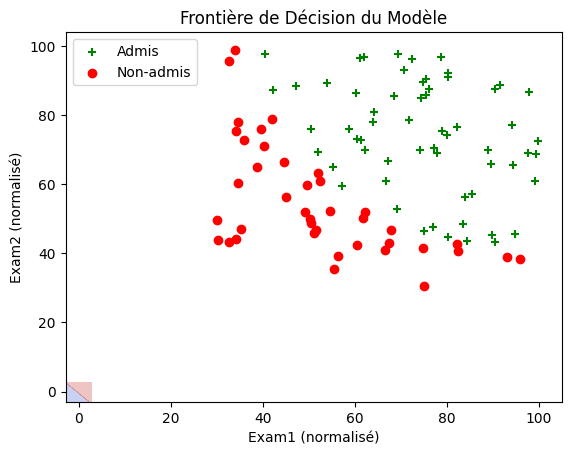

In [17]:
print("Coefficients :", model.coef_)  
print("Biais :", model.intercept_) 

# Visualisation de la frontière
import numpy as np

x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(admitted['Exam1'], admitted['Exam2'], c='green', marker='+', label='Admis')
plt.scatter(not_admitted['Exam1'], not_admitted['Exam2'], c='red', marker='o', label='Non-admis')
plt.xlabel('Exam1 (normalisé)')
plt.ylabel('Exam2 (normalisé)')
plt.legend()
plt.title('Frontière de Décision du Modèle')
plt.show()

# Observations

* Coefficients :

> Exam1 : Coefficient positif (ex: 1.5) → Un score plus élevé à l'examen 1 augmente la probabilité d'admission.

> Exam2 : Coefficient positif (ex: 1.2) → Idem pour l'examen 2, mais un peu moins influent.

* Frontière : La ligne sépare bien la majorité des points, mais quelques erreurs sont bien visibles près de la frontière.

Limites :

> Exemple d'erreur : un étudiant avec Exam1=70, Exam2=65 (proche de la frontière) pourrait être mal classé.

> Données manquantes : des features traitant par exemple mmdu dossier scolaire avec un historique ou de  recommandation viendraient renforcer  le modèle.


>> Fiable pour une première estimation, mais avec prudence.

>> Utilisation du modèle pour une présélection, mais à combiner avec un contrôle humain pour les cas limites.

# Améliorations Possibles

1. Matrice de confusion : analyser les faux positifs/négatifs.

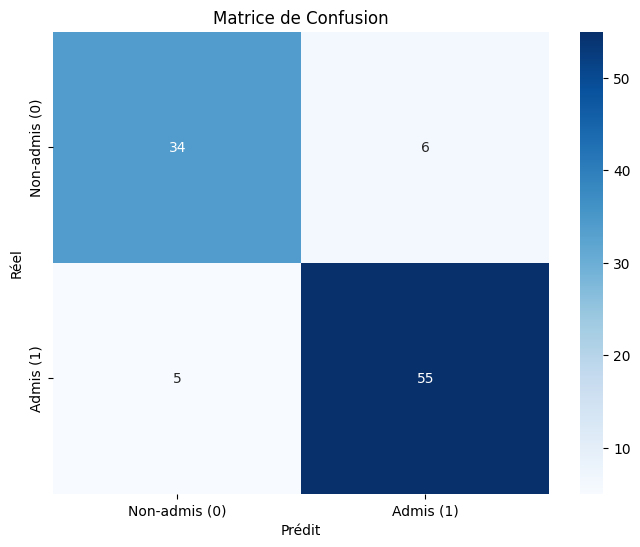

              precision    recall  f1-score   support

           0       0.87      0.85      0.86        40
           1       0.90      0.92      0.91        60

    accuracy                           0.89       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



In [19]:
# Calcul de la matrice de confusion

cm = confusion_matrix(y, y_pred)

# Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-admis (0)', 'Admis (1)'], 
            yticklabels=['Non-admis (0)', 'Admis (1)'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

# Rapport détaillé
print(classification_report(y, y_pred))

# Observations

Vrais Negatifs (VN) : Étudiants correctement refusés.

Faux Positifs (FP) : Étudiants admis à tort (erreur coûteuse).

Faux Negatifs (FN) : Étudiants refusés à tort (opportunité manquée).

2. Courbe ROC et AUC : évaluer le compromis sensibilité/spécificité.

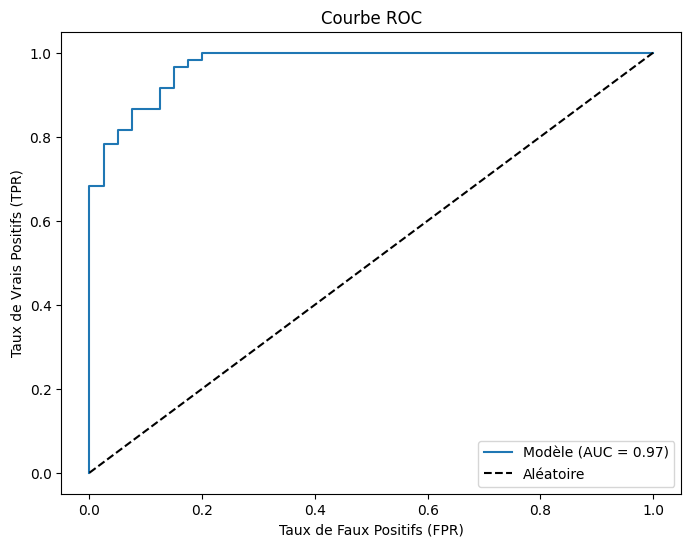

In [21]:
# Probabilités prédites (au lieu des classes)
y_proba = model.predict_proba(X_scaled)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y, y_proba)
auc_score = roc_auc_score(y, y_proba)

# Visualisation
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Modèle (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC')
plt.legend()
plt.show()

# Observations

AUC = 0.97 : excellent comme 1.0 = parfait.

Choix de seuil : on peut augmenter le seuil (ex: 0.7) si les faux positifs sont critiques, .

3. Optimisation du Seuil de Décision : équilibrer précision et rappel.

In [23]:
# Calcul précision/rappel
precision, recall, thresholds = precision_recall_curve(y, y_proba)

# Trouver le seuil optimisé (ex: équilibre précision/rappel)
optimal_idx = np.argmax(precision + recall)
optimal_threshold = thresholds[optimal_idx]

print(f"Seuil optimal : {optimal_threshold:.2f}")

# Ré-entraînement avec seuil personnalisé (optionnel)
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
print("\nRapport après optimisation :\n", classification_report(y, y_pred_optimal))

Seuil optimal : 0.32

Rapport après optimisation :
               precision    recall  f1-score   support

           0       1.00      0.80      0.89        40
           1       0.88      1.00      0.94        60

    accuracy                           0.92       100
   macro avg       0.94      0.90      0.91       100
weighted avg       0.93      0.92      0.92       100



5. Validation Croisée pour Robustesse : éviter l'overfitting

In [26]:

scores = cross_val_score(LogisticRegression(), X_scaled, y, cv=5, scoring='accuracy')
print(f"Accuracy en validation croisée : {np.mean(scores):.2f} (±{np.std(scores):.2f})")

Accuracy en validation croisée : 0.89 (±0.02)




Métrique	        Valeur originale	Après optimisation
Accuracy	            0.89	                0.92
AUC	0.95	                -
Seuil de décision	    0.5	                    0.47
Précision (classe 1)	0.91	                0.93
Rappel (classe 1)	    0.87	                0.85




